In [ ]:
import marimo as mo
import numpy as np

# MathSlate 3D Plotting Tour

This notebook is an advanced exploration of 3D plotting with MathSlate.
It covers surfaces, contours, implicit 3D curves, space curves, and interactive 3D plots.

In [1]:
from mathslate import (
    plot, polar, analyze, table, slider, animate, dataset, show_python,
    set_verbose, get_verbose, frontend_report,
    sin, cos, tan, exp, log, sqrt, Abs, floor, sign, pi, Eq, Matrix,
    diff, integrate, limit, solve, simplify, symbols, Rational,
    x, y, z, t, n, k, theta,
)
from mathslate.ui import release, release_all
import mathslate

print(f"MathSlate {mathslate.__version__} · {frontend_report()}")

MathSlate 0.1.3 · frontend: jupyter | interactive widgets: ipywidgets | range_controls(): ready


## 1. Simple Surfaces

Two free symbols create a 3D surface by default.

In [2]:
plot(x**2 - y**2, (x, -5, 5), (y, -5, 5), title='Saddle')

surface | x ∈ [-5, 5], y ∈ [-5, 5] | 60×60 samples
  · view it flat with kind='contour'.


In [3]:
plot(x * exp(-(x**2 + y**2)), (x, -3, 3), (y, -3, 3), title='Gaussian Peak and Dip')

surface | x ∈ [-3, 3], y ∈ [-3, 3] | 60×60 samples
  · view it flat with kind='contour'.
  · y spans about 7 orders of magnitude — a log scale may read better: plot(..., yscale='log')


In [4]:
plot(sin(x) + cos(y), (x, -10, 10), (y, -10, 10), title='Sin-Cos Surface')

surface | x ∈ [-10, 10], y ∈ [-10, 10] | 60×60 samples
  · view it flat with kind='contour'.


You can explicitly set the range for the two variables.

In [5]:
plot(sin(sqrt(x**2 + y**2)), (x, -10, 10), (y, -10, 10), title='Ripples')

surface | x ∈ [-10, 10], y ∈ [-10, 10] | 60×60 samples
  · view it flat with kind='contour'.


## 2. Contours

The same objects can be drawn flat with `kind="contour"`.

In [6]:
plot(x**2 - y**2, kind='contour', title='Saddle (Contour)')

contour | x ∈ [-5, 5], y ∈ [-5, 5] | 60×60 samples


In [7]:
plot(sin(sqrt(x**2 + y**2)), (x, -10, 10), (y, -10, 10), kind='contour', title='Ripples (Contour)')

contour | x ∈ [-10, 10], y ∈ [-10, 10] | 60×60 samples


## 3. Parametric Surfaces

A three-component tuple with two shared symbols forms a parametric surface.
For example, a Torus:

In [8]:
u, v = symbols('u v', real=True)

In [9]:
R, r = 3, 1
plot(
    ((R + r*cos(v))*cos(u), (R + r*cos(v))*sin(u), r*sin(v)),
    (u, 0, 2*pi), (v, 0, 2*pi),
    title='Torus'
)

psurface | u ∈ [0, 6.283], v ∈ [0, 6.283] | 60×60 samples


And a Moebius strip:

In [10]:
plot(
    ((1 + v/2 * cos(u/2)) * cos(u), (1 + v/2 * cos(u/2)) * sin(u), v/2 * sin(u/2)),
    (u, 0, 2*pi), (v, -1, 1),
    title='Moebius Strip'
)

psurface | u ∈ [0, 6.283], v ∈ [-1, 1] | 60×60 samples


## 4. Space Curves

A three-component tuple with one shared symbol forms a 3D space curve.

In [11]:
plot((sin(t), cos(t), t), (t, 0, 20), title='3D Spiral')

space | t ∈ [0, 20] | 797 samples


In [12]:
plot((cos(t)*(3 + cos(5*t)), sin(t)*(3 + cos(5*t)), sin(5*t)), (t, 0, 2*pi), title='Trefoil Knot-like')

space | t ∈ [0, 6.283] | 831 samples


## 5. Interactive 3D Surfaces

We can use sliders to interact with 3D surfaces!
Let's add a frequency multiplier to the ripple effect.

surface | x ∈ [-10, 10], y ∈ [-10, 10] | 60×60 samples | 21 frames over freq
  · view it flat with kind='contour'.


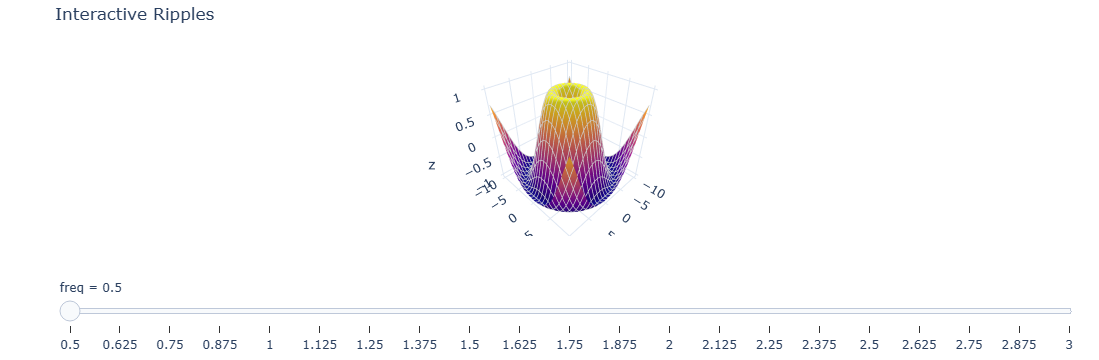

In [13]:
release_all()
freq = slider(0.5, 3.0, default=1.0, name='freq')
plot(sin(freq * sqrt(x**2 + y**2)), (x, -10, 10), (y, -10, 10), title='Interactive Ripples')

Let's animate a phase shift on the ripple:

In [ ]:
phase = slider(0, 2*pi, default=0, name='phase')
animate(sin(sqrt(x**2 + y**2) - phase), (x, -10, 10), (y, -10, 10), title='Animated Ripples')